In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [4]:
transform = transforms.ToTensor()  

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [5]:
def get_batch_accuracy(output, y):
    pred = output.argmax(dim=1)
    return (pred == y).float().mean().item()

In [6]:
def train(model, train_loader, test_loader, criterion, optimizer, epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        model.train()
        train_loss = 0.0
        train_acc = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch)

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = train_acc / len(train_loader)

        model.eval()
        test_loss = 0.0
        test_acc = 0.0

        with torch.no_grad():
            for X_test, y_test in test_loader:
                X_test, y_test = X_test.to(device), y_test.to(device)

                outputs = model(X_test)
                loss = criterion(outputs, y_test)

                test_loss += loss.item() * X_test.size(0)
                test_acc += get_batch_accuracy(outputs, y_test)

        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = test_acc / len(test_loader)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(epoch_test_acc)

    return res

In [7]:
model1 = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(16*16*16, 10)
).to(device)

In [8]:
model2 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(64*8*8, 10)
).to(device)

In [9]:
model3 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128*4*4, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [10]:
epochs = 10
criterion = nn.CrossEntropyLoss()

# Modelo 1
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)
res1 = train(model1, train_loader, test_loader, criterion, optimizer1, epochs)

# Modelo 2
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
res2 = train(model2, train_loader, test_loader, criterion, optimizer2, epochs)

# Modelo 3
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)
res3 = train(model3, train_loader, test_loader, criterion, optimizer3, epochs)

Training: 100%|██████████| 10/10 [07:52<00:00, 47.23s/epoch, test_acc=0.7409, test_loss=0.7960, train_acc=0.8224, train_loss=0.5086]


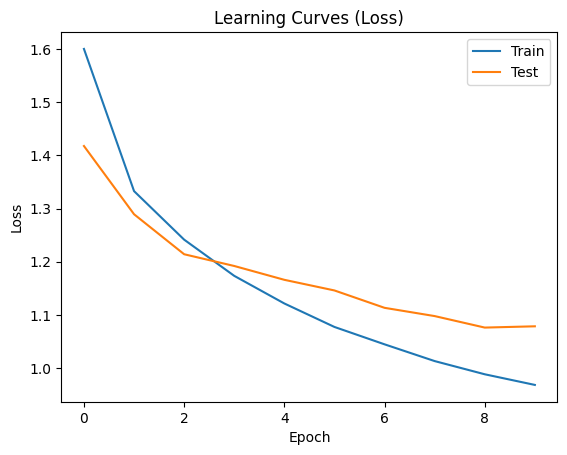

In [11]:
plt.plot(res1['train_loss'], label="Train")
plt.plot(res1['test_loss'], label="Test")

plt.legend()
plt.title("Learning Curves (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

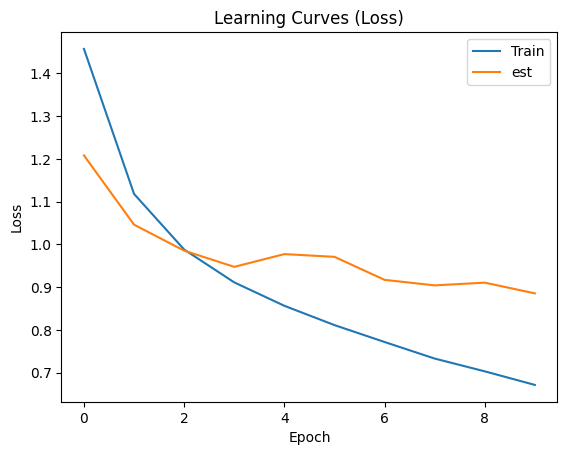

In [12]:
plt.plot(res2['train_loss'], label="Train")
plt.plot(res2['test_loss'], label="est")


plt.legend()
plt.title("Learning Curves (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

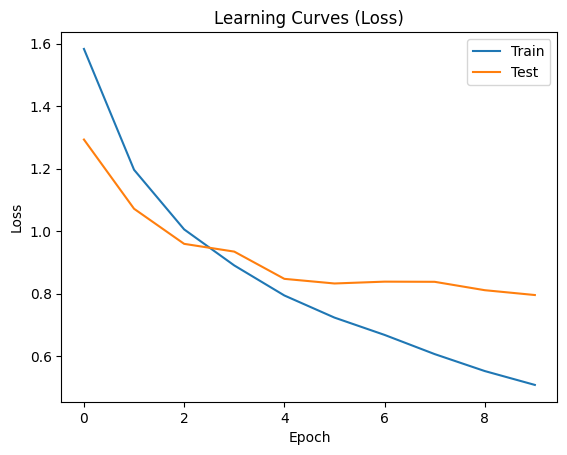

In [13]:
plt.plot(res3['train_loss'], label="Train")
plt.plot(res3['test_loss'], label="Test")


plt.legend()
plt.title("Learning Curves (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
def test_accuracy(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)

            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [15]:
print("Model1 Acc:", test_accuracy(model1))
print("Model2 Acc:", test_accuracy(model2))
print("Model3 Acc:", test_accuracy(model3))

Model1 Acc: 0.6266
Model2 Acc: 0.7045
Model3 Acc: 0.7409


Usando el dataset de CIFAR 10, pude ver que mientras mas capas tenga un modelo mejora su desempeño, supongo que permite reducir la dimensionalidad de las imagenes y extraer patrones, comparando los 3 modelos, el mas complejo fue el de mejor rendimiento a pesar de que solo fueron 10 epochs, ya que los demas muestran bastante overfitting.